# UniswapX Intents and RFQ Lifecycle Analysis

Polaris standardizes RFQs, quotes, executable intents, and settlement observations into one
[Intents and RFQs](https://docs.polaris.supply/schemas/intents-and-rfqs) schema. This notebook
explores live UniswapX observations, contrasts canonical and venue-native fields, follows identifiers
through lifecycle updates, and measures asset-flow and status activity.

Public coverage may contain executable intents without RFQ or quote rows. That is treated as an
observed property of the selected data—not as zero-valued RFQ activity.


## Setup

The example reads the public preview day from catalog metadata and searches its first bounded
windows for data. It caps the iterator at 25,000 observations.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from polaris_data import PolarisClient

for _candidate in (Path.cwd() / "notebooks", Path.cwd()):
    if (_candidate / "_polaris.py").exists():
        sys.path.insert(0, str(_candidate))
        break

from _polaris import accessible_bounds, bounded_rows, event_timestamp

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
warnings.filterwarnings("ignore", message=r".*snapshot coverage.*", category=UserWarning)


In [2]:
source = "uniswapx"
market = "intents"
window_length = pd.Timedelta(minutes=20)
max_rows = 25_000


## Discover public intent coverage

Preview datasets expose one catalog-designated UTC day without credentials. The SDK raises for
ranges outside that day, so the notebook intersects catalog coverage with `public_cutoff_date`.


In [3]:
with PolarisClient() as client:
    catalog = client.catalog(source=source, market=market)

market_info = catalog["markets"][0]
available_start, available_end = accessible_bounds(market_info)
print(f"No-key coverage: {available_start} -> {available_end}")
pd.Series(market_info)


No-key coverage: 2026-09-01 00:00:00+00:00 -> 2026-09-02 00:00:00+00:00


access                                        {'public_cutoff_date': '2026-09-01', 'status': 'preview'}
categories                                                                                           []
end                                                                            2026-09-02T23:51:47.260Z
instrument     {'base': None, 'lot_size': None, 'min_notional': None, 'quote': None, 'tick_size': None}
market                                                                                          intents
source                                                                                         uniswapx
source_type                                                                                        None
start                                                                          2026-08-25T11:10:35.802Z
symbol                                                                                          intents
dtype: object

## Fetch the first populated bounded window

Intent sources can have gaps. Up to six consecutive 20-minute windows are checked, and the first
populated one becomes the analysis range.


In [4]:
intent_rows = []
truncated = False
selected_start = selected_end = None

with PolarisClient() as client:
    for offset in range(6):
        candidate_start = available_start + offset * window_length
        candidate_end = min(candidate_start + window_length, available_end)
        if candidate_start >= candidate_end:
            break
        candidate_rows, candidate_truncated = bounded_rows(
            client.intents(
                source=source, market=market, from_=candidate_start, to=candidate_end, allow_gaps=True,
            ),
            max_rows,
        )
        if candidate_rows:
            intent_rows = candidate_rows
            truncated = candidate_truncated
            selected_start, selected_end = candidate_start, candidate_end
            break

if not intent_rows:
    raise ValueError("No public intent observations were found in the first two accessible hours")

print(f"Selected window: {selected_start} -> {selected_end}")
print(f"Rows materialized: {len(intent_rows):,}; hit cap: {truncated}")


Selected window: 2026-09-01 00:00:00+00:00 -> 2026-09-01 00:20:00+00:00
Rows materialized: 138; hit cap: False


## Canonical shape versus raw venue payload

Canonical fields under `data` are intended for cross-venue analysis. `raw` retains the captured
venue payload when available. Numeric asset amounts remain strings to preserve source precision.


In [5]:
first = intent_rows[0]
canonical_preview = {
    "envelope": {key: first.get(key) for key in [
        "collector_timestamp", "collector_sequence", "source", "market", "type"
    ]},
    "canonical_data": first.get("data", {}),
    "raw_top_level_keys": sorted((first.get("raw") or {}).keys()),
}
canonical_preview


{'envelope': {'collector_timestamp': 1788220813403,
  'collector_sequence': 53,
  'source': 'uniswapx',
  'market': 'intents',
  'type': 'intent'},
 'canonical_data': {'amount_kind': 'exact_input',
  'inputs': [{'amount': '86492448490405019481',
    'asset_id': 'eip155:4663/erc20:0x9e7abd3c9139d14e4c86dce0e455aab7a0c2fb3e',
    'chain_id': 'eip155:4663'}],
  'intent_id': '0xa693afa2f95a46354ccc32db2c8c97177b3c7d5304f9fa112d54f36b43461d1d',
  'outputs': [{'amount': '1604054384',
    'asset_id': 'eip155:4663/erc20:0x5fc5360d0400a0fd4f2af552add042d716f1d168',
    'chain_id': 'eip155:4663',
    'recipient': '0x88ae88fda58aa6d0bc06eaf8d5ccc82dfd9e3072'}],
  'quote': {'quote_id': 'be7e691f-bb36-4c7a-bb9b-f9e045219d81',
   'response': []},
  'rfq_id': '062ddce7-9dc7-425f-912c-d2b4dfb71811',
  'signer': '0x88ae88fda58aa6d0bc06eaf8d5ccc82dfd9e3072',
  'status': 'open',
  'transactions': []},
 'raw_top_level_keys': ['chainId', 'feed', 'payload']}

In [6]:
records = []
for row in intent_rows:
    data = row.get("data") or {}
    quote = data.get("quote") or {}
    inputs = data.get("inputs") or []
    outputs = data.get("outputs") or []
    correlation_id = data.get("intent_id") or data.get("rfq_id")
    records.append({
        "timestamp": event_timestamp(row),
        "correlation_id": correlation_id,
        "intent_id": data.get("intent_id"),
        "rfq_id": data.get("rfq_id"),
        "quote_id": quote.get("quote_id"),
        "status": data.get("status"),
        "amount_kind": data.get("amount_kind"),
        "input_asset": inputs[0].get("asset_id") if inputs else None,
        "output_asset": outputs[0].get("asset_id") if outputs else None,
        "input_count": len(inputs),
        "output_count": len(outputs),
        "transaction_count": len(data.get("transactions") or []),
        "has_raw": "raw" in row,
    })

intents_df = pd.DataFrame(records).sort_values("timestamp")
field_coverage = (
    intents_df.notna().mean().mul(100).round(1).rename("populated_percent").to_frame()
)
field_coverage


,populated_percent
timestamp,100.0
correlation_id,100.0
intent_id,100.0
rfq_id,95.7
quote_id,95.7
status,100.0
amount_kind,100.0
input_asset,100.0
output_asset,100.0
input_count,100.0


## RFQ, quote, and lifecycle coverage

Rows are observations rather than pre-joined lifecycles. `intent_id` and `rfq_id` are used as
correlation keys; status transitions remain in storage order.


In [7]:
coverage_summary = pd.DataFrame([{
    "observations": len(intents_df),
    "unique_correlations": intents_df["correlation_id"].nunique(),
    "intent_rows": intents_df["intent_id"].notna().sum(),
    "rfq_rows": intents_df["rfq_id"].notna().sum(),
    "quote_rows": intents_df["quote_id"].notna().sum(),
    "settlement_rows": intents_df["transaction_count"].gt(0).sum(),
}])
display(coverage_summary)

if coverage_summary.loc[0, "rfq_rows"] == 0:
    print("No RFQ observations were published in this public UniswapX sample.")
if coverage_summary.loc[0, "quote_rows"] == 0:
    print("No quote observations were published in this public UniswapX sample.")

lifecycle_summary = (
    intents_df.dropna(subset=["correlation_id"])
    .groupby("correlation_id")
    .agg(
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
        observations=("timestamp", "size"),
        statuses=("status", lambda values: " -> ".join(dict.fromkeys(values.dropna().astype(str)))),
        settlement_updates=("transaction_count", lambda values: values.gt(0).sum()),
    )
    .sort_values(["observations", "last_seen"], ascending=False)
)
lifecycle_summary.head(10)


,observations,unique_correlations,intent_rows,rfq_rows,quote_rows,settlement_rows
0,138,73,138,132,132,68


,first_seen,last_seen,observations,statuses,settlement_updates
correlation_id,,,,,
0x8c73a6119ee03fa870c705681844f8916fae2e8975019e23e2bfca9d429aa459,2026-09-01 00:19:13.604000+00:00,2026-09-01 00:19:19.145000+00:00,2,open -> filled,1
0xe68db3d094676459dc6fa76fdb2458ce46c3fa6afaaa09465409760c18486b8e,2026-09-01 00:18:44.633000+00:00,2026-09-01 00:19:02.324000+00:00,2,open -> filled,1
0xbbf2ceacb0ca09596b8b87a84af41f43bca8b2c120f5a8c13293d9e7a9bab032,2026-09-01 00:18:44.641000+00:00,2026-09-01 00:18:50.547000+00:00,2,open -> filled,1
0xe8c58833f7b4a20427fd7c5a74385167a8561c11fe556173444493e97d208bee,2026-09-01 00:12:34.500000+00:00,2026-09-01 00:18:44.892000+00:00,2,open -> filled,1
0xf23c1b3f47b1dd88baa716e85d1b9f7ac5691b6637b62230429f6bafd376d681,2026-09-01 00:18:27.356000+00:00,2026-09-01 00:18:33.515000+00:00,2,open -> filled,1
0x7cb3fdaa7061cbe928ecc62540ac1c8457bd6bab0a7e158bd85ba67980da71da,2026-09-01 00:17:28.756000+00:00,2026-09-01 00:17:40.170000+00:00,2,open -> filled,1
0x3a337823bc5554bbf4e6940566cdbba27888767bcaa2a538da82887240cb7e18,2026-09-01 00:17:22.610000+00:00,2026-09-01 00:17:33.923000+00:00,2,open -> filled,1
0x1a2fa38128946b0e8b422ed0cee6c44d5ec4cbc48d9e0e692d340c02af85e055,2026-09-01 00:17:06.516000+00:00,2026-09-01 00:17:22.956000+00:00,2,open -> filled,1
0x48d0227e9dfc5073606e1fdf035d6a8c3b743c860ac23f6de7762ca70d8125da,2026-09-01 00:17:01.959000+00:00,2026-09-01 00:17:07.920000+00:00,2,open -> filled,1


## Status activity and canonical asset flows

Asset identifiers remain canonical CAIP-style strings when chain metadata is available. The charts
intentionally count observations rather than treating incomparable token base units as one volume.


,observations
asset_pair,
0x5fc5360d04 → 0x98096d17e1,16
0x9e7abd3c91 → 0x5fc5360d04,4
0xa0b86991c6 → 0x0000000000,4
0x020bfc650a → 0x5fc5360d04,4
0x5fc5360d04 → 0x57c0e45cb5,4
0x85856f025b → 0x0000000000,4
0x6985884c43 → 0x0000000000,4
0x98096d17e1 → 0x5fc5360d04,4
0x514910771a → 0x0000000000,3


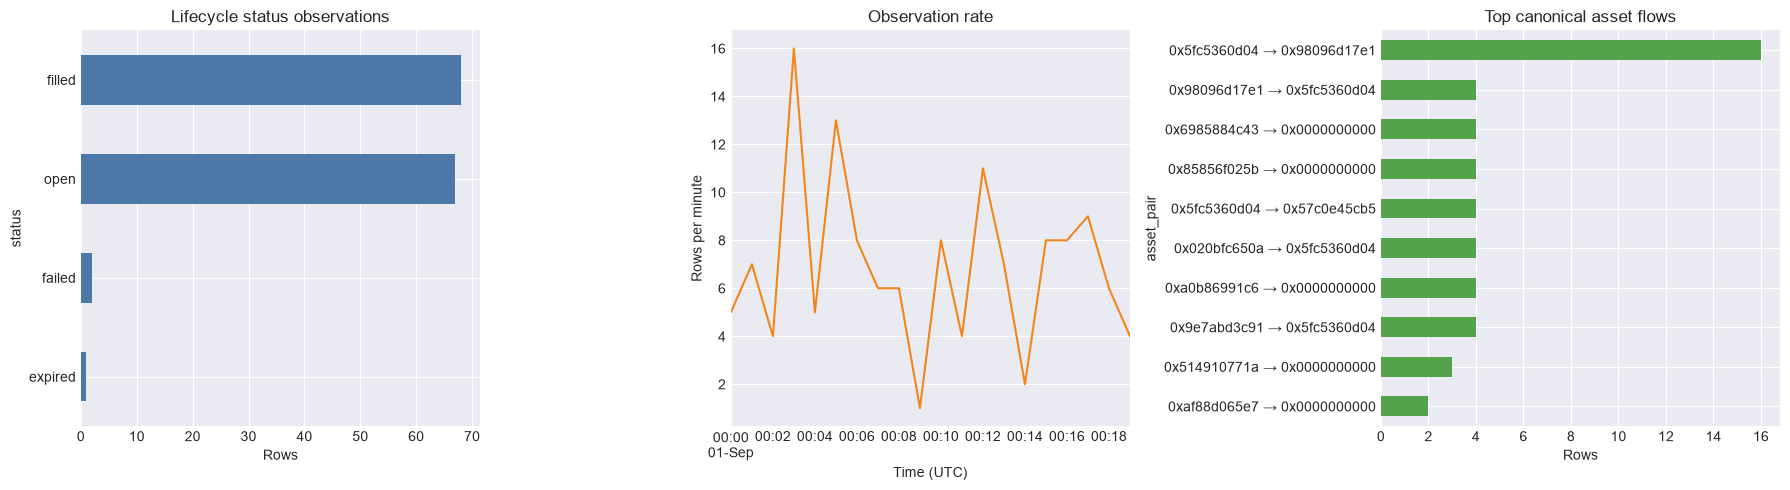

In [8]:
intents_df["asset_pair"] = (
    intents_df["input_asset"].fillna("unknown").str.rsplit(":", n=1).str[-1].str.slice(0, 12)
    + " → "
    + intents_df["output_asset"].fillna("unknown").str.rsplit(":", n=1).str[-1].str.slice(0, 12)
)
status_counts = intents_df["status"].fillna("unspecified").value_counts()
pair_counts = intents_df["asset_pair"].value_counts().head(10)
observations_per_minute = intents_df.set_index("timestamp").resample("1min").size()

display(pair_counts.rename("observations").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
status_counts.sort_values().plot.barh(ax=axes[0], color="#4c78a8")
axes[0].set_title("Lifecycle status observations")
axes[0].set_xlabel("Rows")

observations_per_minute.plot(ax=axes[1], color="#f58518")
axes[1].set_title("Observation rate")
axes[1].set_ylabel("Rows per minute")
axes[1].set_xlabel("Time (UTC)")

pair_counts.sort_values().plot.barh(ax=axes[2], color="#54a24b")
axes[2].set_title("Top canonical asset flows")
axes[2].set_xlabel("Rows")

plt.tight_layout()
plt.show()
